코드 basic-classifier

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
import pandas as pd

file_path = '/content/drive/MyDrive/1_2026_ 미디어이해/AI_Media_Sample_Dataset_500.xlsx'
df = pd.read_excel(file_path)

articles_text = df['Text']
y = df['Frame']

print(df.head())

   ID        Title                      Text Frame  Sentiment  Trust  \
0   1   AI 개인정보 논란        개인정보 보호 문제가 제기되었다.    갈등      -0.56   3.19   
1   2   AI 개인정보 논란        개인정보 보호 문제가 제기되었다.    갈등       0.29   2.58   
2   3    AI 반도체 투자     기업의 AI 반도체 투자가 확대되었다.    경제       0.47   4.25   
3   4  정부 AI 정책 발표    정부가 AI 산업 육성 정책을 발표했다.    책임       0.54   2.90   
4   5     AI 규제 토론  AI 규제 필요성을 둘러싼 논쟁이 이어졌다.    갈등      -0.45   3.45   

   Engagement  Age  Income  AI_Literacy  Purchase_Intention  
0         557   28    8533         2.31                3.33  
1         291   33    4405         3.52                2.56  
2         959   34    6179         3.77                3.99  
3         965   41    4776         2.47                3.23  
4         835   42    7445         2.79                2.78  


In [29]:
!pip install konlpy

In [23]:
# Install MeCab for konlpy using eunjeon
!apt-get update
!apt-get install -y mecab libmecab-dev mecab-utils
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)
!pip install eunjeon

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,632 B in 2s (1,607 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libmecab-dev is already the newest version (0.996-

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from eunjeon import Mecab as EunjeonMecab # Use Eunjeon's Mecab
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Text preprocessing (copied from cell FyS1pbPp9uwb)
# Provide the explicit path to the MeCab dictionary configuration file (mecabrc)
mecab = EunjeonMecab(dicpath='/usr/local/etc/mecabrc')

def korean_tokenizer(text):
    pos_tags = mecab.pos(text)
    # 명사·동사·형용사만 추출
    tokens = [word for word, tag in pos_tags
              if tag.startswith(('NN', 'VV', 'VA'))]
    return tokens

vectorizer = TfidfVectorizer(
    tokenizer=korean_tokenizer,
    max_features=5000,      # 상위 5,000개 어휘
    min_df=5,                # 5개 이상 문서에 출현
    max_df=0.7,              # 70% 이상 문서에 출현하는 단어 제외
    ngram_range=(1, 2)       # 단어와 2-그램 모두 포함
)

# Create feature matrix X and feature names (assuming articles_text and y are already defined)
X = vectorizer.fit_transform(articles_text)
feature_names = vectorizer.get_feature_names_out()

# 학습-시험 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 학습
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
print(f"정확도: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

# 계수 해석
for name, coef in zip(feature_names, model.coef_[0]):
    print(f"{name}: β={coef:.3f}, 오즈비={np.exp(coef):.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


정확도: 1.000
              precision    recall  f1-score   support

          갈등       1.00      1.00      1.00        29
          경제       1.00      1.00      1.00        22
          도덕       1.00      1.00      1.00        26
          책임       1.00      1.00      1.00        23

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

개인: β=0.994, 오즈비=2.702
개인 정보: β=0.994, 오즈비=2.702
교육: β=-0.364, 오즈비=0.695
교육 확대: β=-0.364, 오즈비=0.695
규모: β=-0.367, 오즈비=0.692
규모 증가: β=-0.367, 오즈비=0.692
규제: β=0.962, 오즈비=2.616
규제 필요: β=0.962, 오즈비=2.616
기반: β=-0.386, 오즈비=0.680
기반 복지: β=-0.386, 오즈비=0.680
기업: β=-0.347, 오즈비=0.707
기업 반도체: β=-0.347, 오즈비=0.707
논쟁: β=0.962, 오즈비=2.616
논쟁 이어졌: β=0.962, 오즈비=2.616
높였: β=-0.379, 오즈비=0.684
대학: β=-0.364, 오즈비=0.695
대학 생성: β=-0.364, 오즈비=0.695
도입: β=-0.386, 오즈비=0.680
둘러싼: β=0.962, 오즈비=2.616
둘러싼 논쟁: β=0.962, 오즈비=2.616
문제: β=0.994, 오즈비=2.702
문제 제기: β=0.994, 오즈비=2.702
반도

In [33]:
# 테스트를 위해 articles_text의 첫 5개 문장에 대해 토큰을 추출하고 출력합니다.
print("korean_tokenizer 테스트 출력:")
for i, text in enumerate(articles_text.head(5)):
    tokens = korean_tokenizer(text)
    print(f"문장 {i+1}: {text}")
    print(f"  토큰: {tokens}")
    print("\n")

korean_tokenizer 테스트 출력:
문장 1: 개인정보 보호 문제가 제기되었다.
  토큰: ['개인', '정보', '보호', '문제', '제기']


문장 2: 개인정보 보호 문제가 제기되었다.
  토큰: ['개인', '정보', '보호', '문제', '제기']


문장 3: 기업의 AI 반도체 투자가 확대되었다.
  토큰: ['기업', '반도체', '투자', '확대']


문장 4: 정부가 AI 산업 육성 정책을 발표했다.
  토큰: ['정부', '산업', '육성', '정책', '발표']


문장 5: AI 규제 필요성을 둘러싼 논쟁이 이어졌다.
  토큰: ['규제', '필요', '둘러싼', '논쟁', '이어졌']




In [34]:
# MeCab 설정 파일(mecabrc)의 실제 위치를 찾습니다.
!find / -name "mecabrc" 2>/dev/null

/usr/local/lib/python3.12/dist-packages/eunjeon/data/mecabrc
/usr/local/etc/mecabrc
/tmp/mecab-0.996-ko-0.9.2/mecabrc
/etc/mecabrc


코드 regression-diagnostics

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.765e+31
Date:                Thu, 16 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:02:50   Log-Likelihood:                 16488.
No. Observations:                 500   AIC:                        -3.296e+04
Df Residuals:                     492   BIC:                        -3.293e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3279   4.62e-17   2.87e+16      0.0

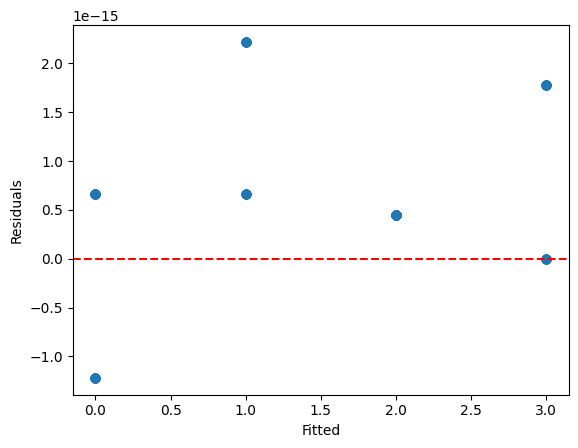

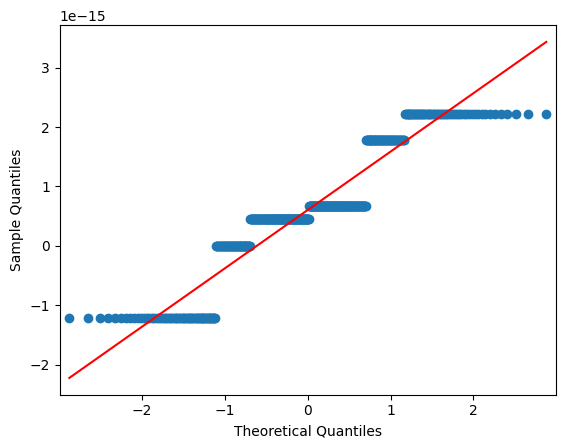

In [37]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 모델 적합
# X가 희소 행렬인 경우, toarray()를 사용하여 밀집 행렬로 변환합니다.
X_with_const = sm.add_constant(X.toarray())

# y를 수치형으로 변환 (OLS는 범주형 종속변수를 직접 처리하지 못합니다)
# LabelEncoder를 사용하여 범주형 y를 수치형으로 변환합니다.
le = LabelEncoder()
y_numeric = le.fit_transform(y)

model = sm.OLS(y_numeric, X_with_const).fit() # y_numeric 사용
print(model.summary())

# 잔차 분석
residuals = model.resid
fitted = model.fittedvalues

# 1) 잔차 vs 적합값 (등분산성 확인)
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted'); plt.ylabel('Residuals')
plt.show()

# 2) Q-Q plot (정규성 확인)
sm.qqplot(residuals, line='s'); plt.show()

코드 regularization-comparison

In [39]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.preprocessing import LabelEncoder # LabelEncoder 임포트

# Assuming X_train, y_train, X_test, y_test are available from previous cells.
# We will use X_test and y_test as X_val and y_val for this cell's context.

# 범주형 y_train과 y_test를 수치형 레이블로 인코딩합니다.
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_test) # y_test를 y_val로 사용합니다.

# 정규화 강도 후보
lambdas = np.logspace(-3, 2, 50)

results = {}
for name, ModelClass in [('Ridge', Ridge), ('Lasso', Lasso),
                          ('ElasticNet', ElasticNet)]:
    val_mse = []
    for alpha in lambdas:
        model = ModelClass(alpha=alpha, max_iter=5000)
        # 인코딩된 y_train과 y_val을 사용합니다.
        model.fit(X_train, y_train_encoded)
        pred = model.predict(X_test) # X_test를 X_val로 사용합니다.
        val_mse.append(mean_squared_error(y_val_encoded, pred))
    best_idx = np.argmin(val_mse)
    results[name] = (lambdas[best_idx], val_mse[best_idx])
    print(f"{name}: 최적 λ={lambdas[best_idx]:.4f}, 검증 MSE={val_mse[best_idx]:.4f}")

Ridge: 최적 λ=0.0010, 검증 MSE=0.0000
Lasso: 최적 λ=0.0010, 검증 MSE=0.0004
ElasticNet: 최적 λ=0.0010, 검증 MSE=0.0002


코드 preprocessing

In [41]:
from eunjeon import Mecab as EunjeonMecab # Use Eunjeon's Mecab
from sklearn.feature_extraction.text import TfidfVectorizer

# Provide the explicit path to the MeCab dictionary configuration file (mecabrc)
mecab = EunjeonMecab(dicpath='/usr/local/etc/mecabrc')

def korean_tokenizer(text):
    pos_tags = mecab.pos(text)
    # 명사·동사·형용사만 추출
    tokens = [word for word, tag in pos_tags
              if tag.startswith(('NN', 'VV', 'VA'))]
    return tokens

vectorizer = TfidfVectorizer(
    tokenizer=korean_tokenizer,
    max_features=5000,      # 상위 5,000개 어휘
    min_df=5,                # 5개 이상 문서에 출현
    max_df=0.7,              # 70% 이상 문서에 출현하는 단어 제외
    ngram_range=(1, 2)       # 단어와 2-그램 모두 포함
)

X = vectorizer.fit_transform(articles_text)
print(f"문서 수: {X.shape[0]}, 어휘 수: {X.shape[1]}")

문서 수: 500, 어휘 수: 60


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


코드 frame-classifier

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 학습-시험 분할 (계층적 샘플링으로 클래스 균형 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# L1 정규화 다항 로지스틱 회귀
model = LogisticRegression(
    penalty='l1',
    solver='saga',
    multi_class='multinomial',
    C=1.0,                  # C = 1/λ; C가 작을수록 강한 정규화
    max_iter=2000,
    random_state=42
)
model.fit(X_train, y_train)

# 평가
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred,
      target_names=['갈등', '책임', '도덕성', '위기']))
print("\n혼동 행렬:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

          갈등       1.00      1.00      1.00        29
          책임       1.00      1.00      1.00        22
         도덕성       1.00      1.00      1.00        26
          위기       1.00      1.00      1.00        23

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


혼동 행렬:
[[29  0  0  0]
 [ 0 22  0  0]
 [ 0  0 26  0]
 [ 0  0  0 23]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


코드 interpret-frames

In [43]:
import pandas as pd

feature_names = vectorizer.get_feature_names_out()
frame_names = ['갈등', '책임', '도덕성', '위기']

for i, frame in enumerate(frame_names):
    coefs = model.coef_[i]
    top_idx = np.argsort(coefs)[-15:][::-1]   # 상위 15개
    top_words = [(feature_names[j], coefs[j]) for j in top_idx]
    print(f"\n[{frame} 프레임 상위 신호 단어]")
    for word, coef in top_words:
        print(f"  {word}: {coef:.3f}")


[갈등 프레임 상위 신호 단어]
  제기: 1.240
  정보: 1.240
  정보 보호: 1.240
  보호: 1.240
  문제: 1.240
  문제 제기: 1.240
  개인: 1.240
  개인 정보: 1.240
  보호 문제: 1.240
  이어졌: 1.184
  필요: 1.184
  필요 둘러싼: 1.184
  둘러싼: 1.184
  둘러싼 논쟁: 1.184
  논쟁: 1.184

[책임 프레임 상위 신호 단어]
  투자: 16.251
  확대: 0.000
  필요: 0.000
  필요 둘러싼: 0.000
  투자 확대: 0.000
  투자 규모: 0.000
  진단 정확도: 0.000
  진단: 0.000
  증가: 0.000
  제기: 0.000
  정확도 높였: 0.000
  정확도: 0.000
  정책 발표: 0.000
  정책: 0.000
  정부 산업: 0.000

[도덕성 프레임 상위 신호 단어]
  서비스: 1.548
  서비스 도입: 1.548
  복지: 1.548
  복지 서비스: 1.548
  기반 복지: 1.548
  도입: 1.548
  기반: 1.548
  진단 정확도: 1.518
  암 진단: 1.518
  암: 1.518
  정확도: 1.518
  정확도 높였: 1.518
  높였: 1.518
  진단: 1.518
  증가: 0.000

[위기 프레임 상위 신호 단어]
  생성 교육: 1.565
  교육: 1.565
  대학 생성: 1.565
  생성: 1.565
  대학: 1.565
  교육 확대: 1.565
  육성 정책: 1.222
  육성: 1.222
  정부: 1.222
  정책: 1.222
  정책 발표: 1.222
  정부 산업: 1.222
  산업 육성: 1.222
  산업: 1.222
  발표: 1.222


# 신규 연구 문제 1

   ID        Title                      Text Frame  Sentiment  Trust  \
0   1   AI 개인정보 논란        개인정보 보호 문제가 제기되었다.    갈등      -0.56   3.19   
1   2   AI 개인정보 논란        개인정보 보호 문제가 제기되었다.    갈등       0.29   2.58   
2   3    AI 반도체 투자     기업의 AI 반도체 투자가 확대되었다.    경제       0.47   4.25   
3   4  정부 AI 정책 발표    정부가 AI 산업 육성 정책을 발표했다.    책임       0.54   2.90   
4   5     AI 규제 토론  AI 규제 필요성을 둘러싼 논쟁이 이어졌다.    갈등      -0.45   3.45   

   Engagement  Age  Income  AI_Literacy  Purchase_Intention  
0         557   28    8533         2.31                3.33  
1         291   33    4405         3.52                2.56  
2         959   34    6179         3.77                3.99  
3         965   41    4776         2.47                3.23  
4         835   42    7445         2.79                2.78  
(500, 35)
Accuracy
1.0
Classification Report
              precision    recall  f1-score   support

          갈등       1.00      1.00      1.00        29
          경제       1.00      1.00      1.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44040 (\N{HANGUL SYLLABLE GAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

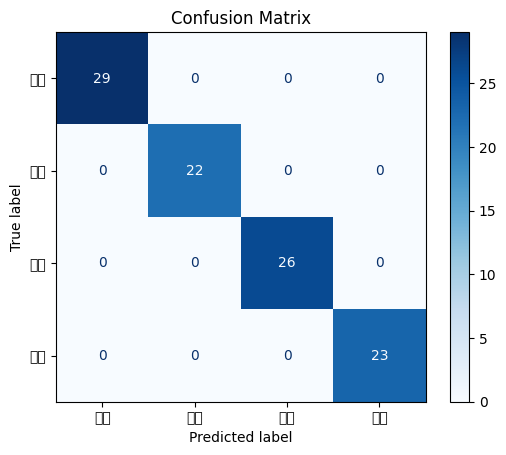

In [45]:
###########################################################
# RQ1
# AI 뉴스 프레임 분류
# Text → TF-IDF → Logistic Regression
###########################################################

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

###########################################################
# 1. 데이터 불러오기
###########################################################

# 파일 경로가 Google Drive에 있으므로, file_path 변수를 사용합니다.
file_path = '/content/drive/MyDrive/1_2026_ 미디어이해/AI_Media_Sample_Dataset_500.xlsx'
df = pd.read_excel(file_path)

print(df.head())

###########################################################
# 2. 독립변수(X), 종속변수(y)
###########################################################

X = df["Text"]

y = df["Frame"]

###########################################################
# 3. TF-IDF
###########################################################

tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(X)

print(X_tfidf.shape)

###########################################################
# 4. Train / Test
###########################################################

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

###########################################################
# 5. Logistic Regression
###########################################################

model = LogisticRegression(
    max_iter=1000,
    random_state=123
)

model.fit(X_train, y_train)

###########################################################
# 6. 예측
###########################################################

y_pred = model.predict(X_test)

###########################################################
# 7. 정확도
###########################################################

accuracy = accuracy_score(y_test, y_pred)

print("="*60)
print("Accuracy")
print("="*60)

print(round(accuracy,4))

###########################################################
# 8. Classification Report
###########################################################

print("="*60)
print("Classification Report")
print("="*60)

print(classification_report(y_test,y_pred))

###########################################################
# 9. Confusion Matrix
###########################################################

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()